Recommendation System

Data Description:

Unique ID of each anime.
Anime title.
Anime broadcast type, such as TV, OVA, etc.
anime genre.
The number of episodes of each anime.
The average rating for each anime compared to the number of users who gave ratings.


Number of community members for each anime.
Objective:
The objective of this assignment is to implement a recommendation system using cosine similarity on an anime dataset. 
Dataset:
Use the Anime Dataset which contains information about various anime, including their titles, genres,No.of episodes and user ratings etc.

Tasks:

Data Preprocessing:

Load the dataset into a suitable data structure (e.g., pandas DataFrame).
Handle missing values, if any.
Explore the dataset to understand its structure and attributes.

Feature Extraction:

Decide on the features that will be used for computing similarity (e.g., genres, user ratings).
Convert categorical features into numerical representations if necessary.
Normalize numerical features if required.

Recommendation System:

Design a function to recommend anime based on cosine similarity.
Given a target anime, recommend a list of similar anime based on cosine similarity scores.
Experiment with different threshold values for similarity scores to adjust the recommendation list size.
Analyze the performance of the recommendation system and identify areas of improvement.

Interview Questions:
1. Can you explain the difference between user-based and item-based collaborative filtering?
2. What is collaborative filtering, and how does it work?

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
# Loading data
df = pd.read_csv("anime.csv")

df

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175


In [4]:
# Loading upper side of data
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [5]:
# loading lower side of data
df.tail()

,anime_id,name,genre,type,episodes,rating,members
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175
12293,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,1,5.46,142


In [6]:
# Checking informatiom of given data 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


# Data Preprocessing

In [8]:
# Shape of the data
df.shape

(12294, 7)

In [9]:
# Checking missing values
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [10]:
# Checking duplicated values
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
12289    False
12290    False
12291    False
12292    False
12293    False
Length: 12294, dtype: bool

In [11]:
# Statistical analysis
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [12]:
# Top 10 anime by ratings
top_rated = df.sort_values('rating', ascending=False)

print(top_rated[['name','rating']].head(10))

                                          name  rating
10464  Taka no Tsume 8: Yoshida-kun no X-Files   10.00
10400              Spoon-hime no Swing Kitchen    9.60
9595                          Mogura no Motoro    9.50
0                               Kimi no Na wa.    9.37
9078                              Kahei no Umi    9.33
1             Fullmetal Alchemist: Brotherhood    9.26
2                                     Gintama°    9.25
10786          Yakusoku: Africa Mizu to Midori    9.25
3                                  Steins;Gate    9.17
4                                Gintama&#039;    9.16


In [13]:
# Top Anime types
print(df['type'].value_counts())

type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: count, dtype: int64


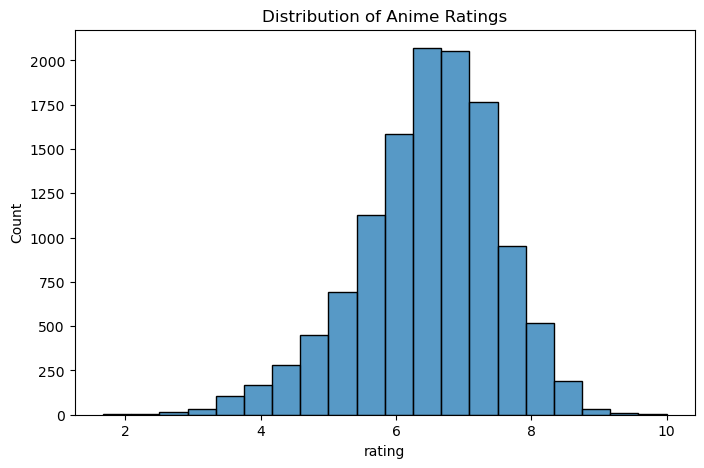

In [14]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20)
plt.title("Distribution of Anime Ratings")
plt.show()

# Feature Extraction


In [16]:
df['genre'] = df['genre'].fillna('Unknown').astype(str)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

genre_matrix = tfidf.fit_transform(df['genre'])

print(genre_matrix.shape)

(12294, 47)


In [18]:
# Convert genre into numeric form
tfidf = TfidfVectorizer(stop_words='english')

genre_matrix = tfidf.fit_transform(df['genre'])

In [19]:
# Cosine similarity matrix
cosine_sim = cosine_similarity(genre_matrix)

In [20]:
# Creatin A Recomadation System
indices = pd.Series(df.index,
                    index=df['name']).drop_duplicates()

In [21]:
def recommend_anime(anime_name,
                    top_n=10):

    idx = indices[anime_name]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores,
                        key=lambda x:x[1],
                        reverse=True)

    sim_scores = sim_scores[1:top_n+1]

    anime_indices = [i[0] for i in sim_scores]

    return df[['name','genre','rating']].iloc[anime_indices]

In [22]:
# Generating recomandation
recommend_anime("Steins;Gate")

,name,genre,rating
59,Steins;Gate Movie: Fuka Ryouiki no Déjà vu,"Sci-Fi, Thriller",8.61
126,Steins;Gate: Oukoubakko no Poriomania,"Sci-Fi, Thriller",8.46
196,Steins;Gate: Kyoukaimenjou no Missing Link - D...,"Sci-Fi, Thriller",8.34
10898,Steins;Gate 0,"Sci-Fi, Thriller",NaN
5126,Under the Dog,"Action, Sci-Fi, Thriller",6.55
5525,Loups=Garous,"Mystery, Sci-Fi, Thriller",6.43
6889,Loups=Garous Pilot,"Mystery, Sci-Fi, Thriller",5.87
5249,Kyoto Animation: Megane-hen,Thriller,6.51
2518,Ibara no Ou,"Action, Mystery, Sci-Fi, Thriller",7.24
5454,Duan Nao,"Mystery, Sci-Fi, Shounen, Thriller",6.42


In [23]:
recommend_anime("Fullmetal Alchemist: Brotherhood")

,name,genre,rating
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",8.33
1558,Fullmetal Alchemist: The Sacred Star of Milos,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",7.50
402,Fullmetal Alchemist: Brotherhood Specials,"Adventure, Drama, Fantasy, Magic, Military, Sh...",8.11
879,Tales of Vesperia: The First Strike,"Action, Adventure, Fantasy, Magic, Military",7.79
4264,Tide-Line Blue,"Action, Adventure, Drama, Military, Shounen",6.77
1967,Fullmetal Alchemist: Reflections,"Adventure, Comedy, Drama, Fantasy, Military, S...",7.39
101,Magi: The Kingdom of Magic,"Action, Adventure, Fantasy, Magic, Shounen",8.50
268,Magi: The Labyrinth of Magic,"Action, Adventure, Fantasy, Magic, Shounen",8.24
290,Magi: Sinbad no Bouken (TV),"Action, Adventure, Fantasy, Magic, Shounen",8.22
461,Magi: Sinbad no Bouken,"Action, Adventure, Fantasy, Magic, Shounen",8.06


## Recomadation using similarity treshold


In [26]:
def recommend_threshold(anime_name,
                        threshold=0.50):

    idx = indices[anime_name]

    scores = list(enumerate(cosine_sim[idx]))

    filtered = [(i,s) for i,s in scores
                if s > threshold and i != idx]

    filtered = sorted(filtered,
                      key=lambda x:x[1],
                      reverse=True)

    anime_ids = [i for i,s in filtered]

    return df[['name','genre','rating']].iloc[anime_ids]

In [27]:
recommend_threshold("Steins;Gate",
                    threshold=0.60)

,name,genre,rating
59,Steins;Gate Movie: Fuka Ryouiki no Déjà vu,"Sci-Fi, Thriller",8.61
126,Steins;Gate: Oukoubakko no Poriomania,"Sci-Fi, Thriller",8.46
196,Steins;Gate: Kyoukaimenjou no Missing Link - D...,"Sci-Fi, Thriller",8.34
10898,Steins;Gate 0,"Sci-Fi, Thriller",NaN
5126,Under the Dog,"Action, Sci-Fi, Thriller",6.55
5525,Loups=Garous,"Mystery, Sci-Fi, Thriller",6.43
6889,Loups=Garous Pilot,"Mystery, Sci-Fi, Thriller",5.87
5249,Kyoto Animation: Megane-hen,Thriller,6.51
2518,Ibara no Ou,"Action, Mystery, Sci-Fi, Thriller",7.24
5454,Duan Nao,"Mystery, Sci-Fi, Shounen, Thriller",6.42


### Observation

* Higher threshold → fewer but highly relevant recommendations.
* Lower threshold → more recommendations but lower similarity.

# Performance Analysis

## Advantages

* Easy to implement.
* Fast recommendation generation.
* Genre-based recommendations are meaningful.
* No user history required.
    
## Limitations
* Considers only content features.
* Does not account for user preferences.
* Cold-start problem for new users.

## Possible Improvements

* Use user ratings dataset.
* Hybrid recommendation system.
* Collaborative filtering.
* Deep learning recommendation models.

# Conclusion

Successfully implemented a content-based recommendation system using cosine similarity.

Genres were converted into numerical vectors using TF-IDF.

Cosine similarity identified anime with similar characteristics.

The recommendation system effectively suggested anime related to the target anime.

Higher similarity thresholds produced more accurate recommendations.

# 1.Can you explain the difference between user-based and item-based collaborative filtering?

User-Based Collaborative Filtering

User-based collaborative filtering recommends items based on similarities between users.

Example:
If User A and User B have similar viewing histories, anime liked by User B can be recommended to User A.

Item-Based Collaborative Filtering

Item-based collaborative filtering recommends items similar to those already liked by the user.

Example:
If a user likes "Steins;Gate", the system recommends anime that other users commonly watch along with "Steins;Gate".

# 2.What is collaborative filtering, and how does it work?

Collaborative filtering is a recommendation technique that predicts user interests based on the preferences and behavior of many users.

### Working Process

Collect user-item interaction data (ratings, likes, watches).
    
Identify similarities among users or items.

Predict missing ratings.
    
Recommend the most relevant items.

Example

If many users who watched Naruto also watched Bleach, then Bleach can be recommended to a Naruto fan.

### Types
User-Based Collaborative Filtering
    
Item-Based Collaborative Filtering

### Advantages
    
Personalized recommendations.
    
Does not require item content information.
    
### Disadvantages

Cold-start problem.
    
Requires sufficient user interaction data.